# Lesson 6 — Gaussian Process Regression

A GP surrogate is the conditional Gaussian formula from Lesson 4, applied using the kernel matrix from Lesson 5.

**Two equations are all you need:**

$$\mu^* = K_s K^{-1} y$$

$$\sigma^{*2} = K_{ss} - K_s K^{-1} K_s^T$$

where $K = k(X, X) + \sigma_n^2 I$ (training covariance + noise), $K_s = k(X_*, X)$ (test-train covariance), $K_{ss} = k(X_*, X_*)$ (test-test covariance).

We never invert $K$ directly — we use Cholesky decomposition for numerical stability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

## Benchmark functions and kernels

We reuse the kernels from Lesson 5 and introduce two benchmark functions we'll use throughout the course.

In [2]:
def forrester(x):
    """Standard 1D benchmark: (6x-2)² sin(12x-4), domain [0,1]."""
    x = np.asarray(x).ravel()
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)

def branin_norm(X):
    """Branin on [0,1]²."""
    X = np.atleast_2d(X)
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    a, b, c = 1.0, 5.1 / (4 * np.pi**2), 5 / np.pi
    r, s, t = 6.0, 10.0, 1 / (8 * np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s

def rbf(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1); X2 = np.atleast_2d(X2)
    diff = X1[:, None, :] - X2[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)
    return signal_var * np.exp(-0.5 * sq_dist / length_scale**2)

def matern52(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1); X2 = np.atleast_2d(X2)
    diff = X1[:, None, :] - X2[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    s = np.sqrt(5) * r / length_scale
    return signal_var * (1 + s + s**2/3) * np.exp(-s)

def matern32(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1); X2 = np.atleast_2d(X2)
    diff = X1[:, None, :] - X2[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    s = np.sqrt(3) * r / length_scale
    return signal_var * (1 + s) * np.exp(-s)

print("Forrester(0.5) =", forrester(0.5))
print("Branin([0.5,0.5]) =", branin_norm([[0.5, 0.5]]))

Forrester(0.5) = [0.90929743]
Branin([0.5,0.5]) = [24.12996441]


## GP core: predict and log marginal likelihood

The Cholesky factorisation $K = L L^T$ lets us solve $K^{-1}y$ as two triangular solves — much more numerically stable than computing $K^{-1}$ directly.

In [4]:
def gp_predict(X_train, y_train, X_test, kernel_fn, noise=1e-4):
    """
    GP posterior mean and std.
    Returns: mu (n_test,), std (n_test,)
    """
    K    = kernel_fn(X_train, X_train) + noise * np.eye(len(X_train))
    Ks   = kernel_fn(X_test, X_train)
    Kss  = kernel_fn(X_test, X_test)
    L    = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu   = Ks @ alpha
    v    = np.linalg.solve(L, Ks.T)
    var  = np.diag(Kss) - np.sum(v**2, axis=0)
    std  = np.sqrt(np.maximum(var, 0))
    return mu, std

def log_marginal_likelihood(X_train, y_train, kernel_fn, noise=1e-4):
    K = kernel_fn(X_train, X_train) + noise * np.eye(len(X_train))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return -np.inf
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    lml  = -0.5 * y_train @ alpha          # data fit term
    lml -= np.sum(np.log(np.diag(L)))      # complexity penalty
    lml -= 0.5 * len(X_train) * np.log(2 * np.pi)
    return float(lml)

def sample_gp_prior(K, n_samples=5, jitter=1e-6):
    K_jit = K + jitter * np.eye(len(K))
    L = np.linalg.cholesky(K_jit)
    z = rng.standard_normal((len(K), n_samples))
    return L @ z

print("GP core functions ready.")

GP core functions ready.


## Part 1 — Prior → Posterior

Before seeing any data the GP places a distribution over all continuous functions consistent with the kernel (the **prior**). After conditioning on observations, the posterior collapses around the data points while keeping high uncertainty elsewhere.

This is exactly the conditional Gaussian from Lesson 4, applied using the kernel matrix from Lesson 5.

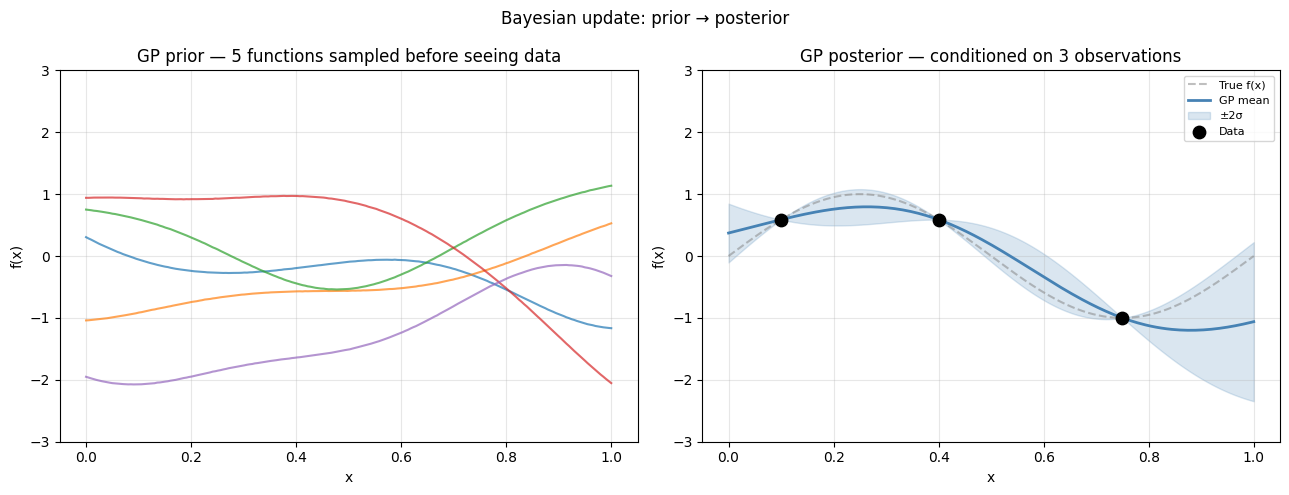

In [5]:
x_fine = np.linspace(0, 1, 200).reshape(-1, 1)
kern   = lambda X1, X2: rbf(X1, X2, length_scale=0.3, signal_var=1.0)

# Prior samples
K_prior = kern(x_fine, x_fine)
prior_samples = sample_gp_prior(K_prior, n_samples=5)

# Condition on 3 observations
x_obs = np.array([[0.1], [0.4], [0.75]])
y_obs = np.sin(2 * np.pi * x_obs.squeeze())
mu_post, std_post = gp_predict(x_obs, y_obs, x_fine, kern, noise=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(5):
    axes[0].plot(x_fine.squeeze(), prior_samples[:, i], linewidth=1.5, alpha=0.7)
axes[0].set_title("GP prior — 5 functions sampled before seeing data")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].set_ylim(-3, 3); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_fine.squeeze(), np.sin(2*np.pi*x_fine.squeeze()),
             color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True f(x)")
axes[1].plot(x_fine.squeeze(), mu_post, color="steelblue", linewidth=2, label="GP mean")
axes[1].fill_between(x_fine.squeeze(),
                     mu_post - 2*std_post, mu_post + 2*std_post,
                     alpha=0.2, color="steelblue", label="±2σ")
axes[1].scatter(x_obs.squeeze(), y_obs, color="black", s=80, zorder=5, label="Data")
axes[1].set_title("GP posterior — conditioned on 3 observations")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].set_ylim(-3, 3); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("Bayesian update: prior → posterior", fontsize=12)
plt.tight_layout()
plt.show()

**Try it:** Change `noise=1e-6` to `noise=0.1` in `gp_predict`. The GP no longer interpolates exactly — it smooths through the data instead. This models noisy observations.

## Part 2 — GP on the Forrester function

The Forrester function $(6x-2)^2 \sin(12x-4)$ is a standard 1D benchmark used throughout surrogate modelling research. It has one global minimum, one local minimum, and one sharp ridge — enough complexity to be interesting.

We fit the GP with 5, 10, and 20 training points to see how uncertainty decreases as we add data.

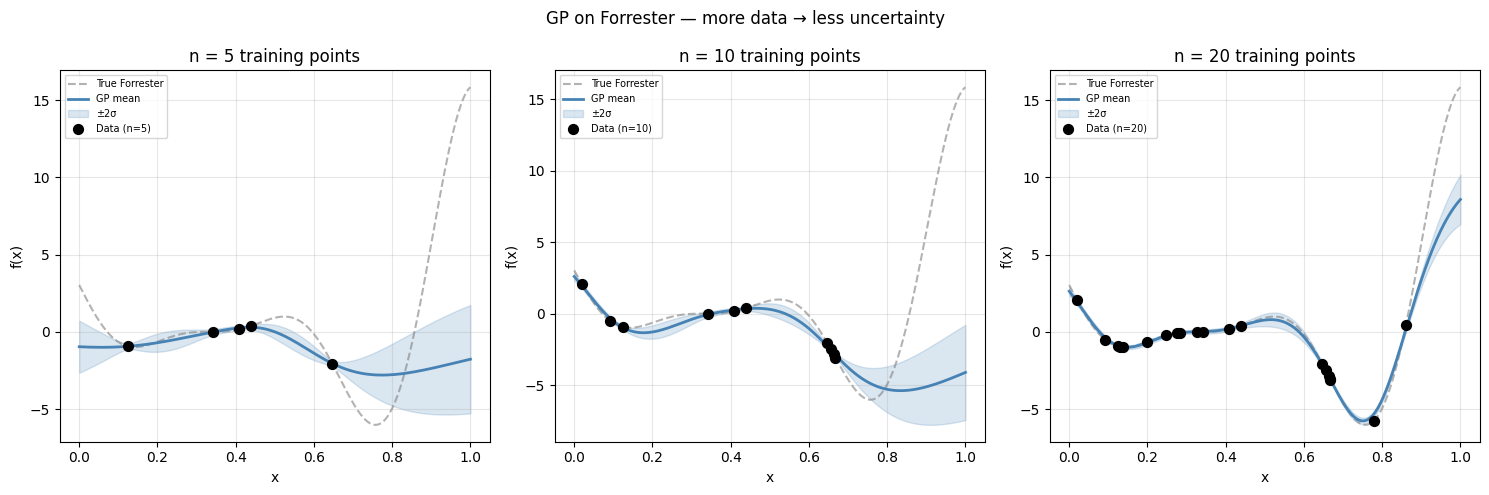

In [6]:
x_all  = rng.uniform(0, 1, 20).reshape(-1, 1)
y_all  = forrester(x_all)
x_true = np.linspace(0, 1, 300).reshape(-1, 1)
y_true = forrester(x_true)

kern_f = lambda X1, X2: matern52(X1, X2, length_scale=0.3, signal_var=4.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, [5, 10, 20]):
    X_tr, y_tr = x_all[:n], y_all[:n]
    mu, std = gp_predict(X_tr, y_tr, x_true, kern_f, noise=0.01)

    ax.plot(x_true.squeeze(), y_true, color="gray", linestyle="--",
            linewidth=1.5, alpha=0.6, label="True Forrester")
    ax.plot(x_true.squeeze(), mu, color="steelblue", linewidth=2, label="GP mean")
    ax.fill_between(x_true.squeeze(), mu-2*std, mu+2*std,
                    alpha=0.2, color="steelblue", label="±2σ")
    ax.scatter(X_tr.squeeze(), y_tr, color="black", s=50, zorder=5, label=f"Data (n={n})")
    ax.set_title(f"n = {n} training points")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("GP on Forrester — more data → less uncertainty", fontsize=12)
plt.tight_layout()
plt.show()

**Try it:** Reduce to `n=3` training points. Notice that the ±2σ band covers almost the whole function range in unsampled regions — the GP is honest about what it does not know.

## Part 3 — Effect of the noise hyperparameter

The noise term $\sigma_n^2$ in $K + \sigma_n^2 I$ has a direct interpretation: how much output variance is due to measurement noise vs. the true function.

- **Low noise** → GP interpolates exactly through the data (overfits noise)
- **High noise** → GP smooths over the data (underfits, widens uncertainty)

In practice we optimise this alongside the kernel hyperparameters using the log marginal likelihood.

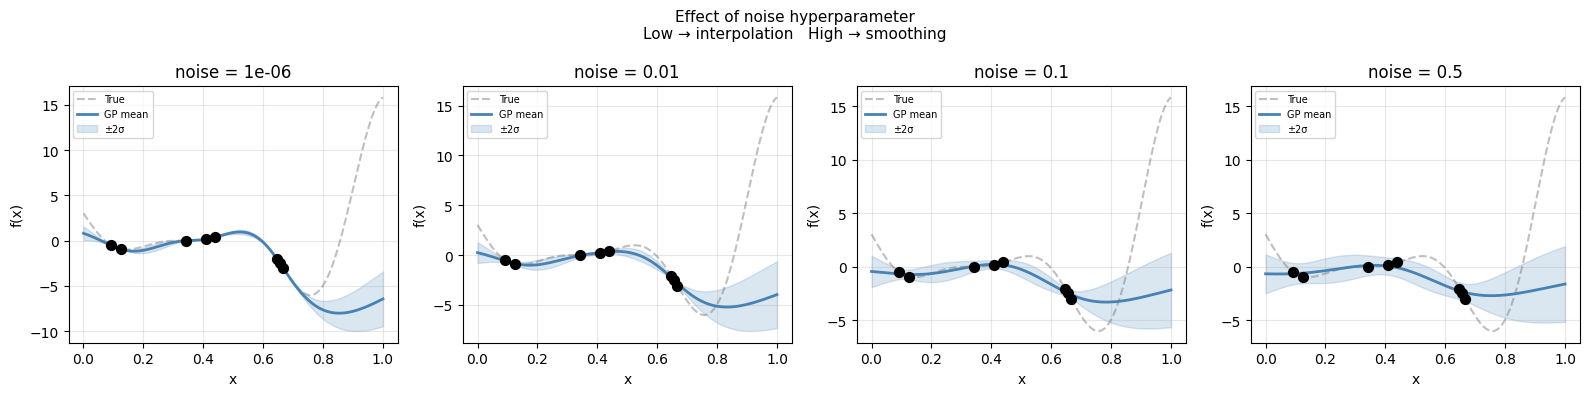

In [7]:
X_tr8, y_tr8 = x_all[:8], y_all[:8]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, noise in zip(axes, [1e-6, 0.01, 0.1, 0.5]):
    mu, std = gp_predict(X_tr8, y_tr8, x_true, kern_f, noise=noise)
    ax.plot(x_true.squeeze(), y_true, color="gray", linestyle="--",
            linewidth=1.5, alpha=0.5, label="True")
    ax.plot(x_true.squeeze(), mu, color="steelblue", linewidth=2, label="GP mean")
    ax.fill_between(x_true.squeeze(), mu-2*std, mu+2*std,
                    alpha=0.2, color="steelblue", label="±2σ")
    ax.scatter(X_tr8.squeeze(), y_tr8, color="black", s=50, zorder=5)
    ax.set_title(f"noise = {noise}")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("Effect of noise hyperparameter\nLow → interpolation   High → smoothing", fontsize=11)
plt.tight_layout()
plt.show()

## Part 4 — Kernel comparison on Forrester

Different kernels encode different beliefs about function smoothness.

The **log marginal likelihood** $\log p(y|X)$ tells us which kernel the data prefers — without a separate validation set. Higher is better.

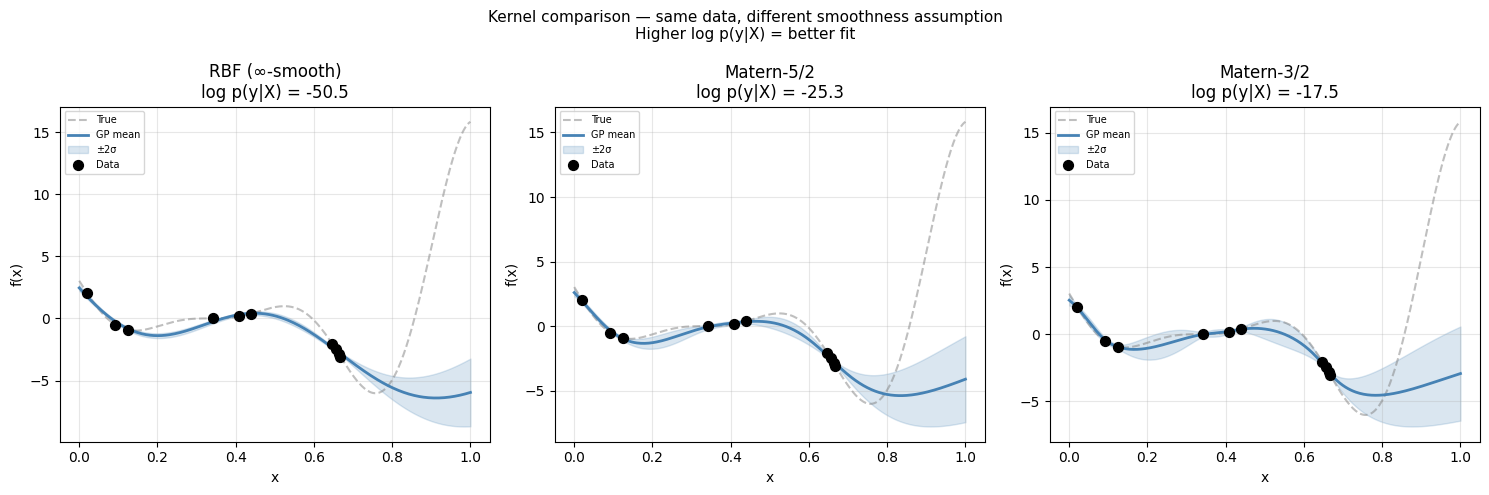

In [8]:
X_tr10, y_tr10 = x_all[:10], y_all[:10]

kernels = [
    ("RBF (∞-smooth)",  lambda X1, X2: rbf(X1, X2, length_scale=0.3, signal_var=4.0)),
    ("Matern-5/2",      lambda X1, X2: matern52(X1, X2, length_scale=0.3, signal_var=4.0)),
    ("Matern-3/2",      lambda X1, X2: matern32(X1, X2, length_scale=0.3, signal_var=4.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, kern_fn) in zip(axes, kernels):
    mu, std = gp_predict(X_tr10, y_tr10, x_true, kern_fn, noise=0.01)
    lml = log_marginal_likelihood(X_tr10, y_tr10, kern_fn, noise=0.01)
    ax.plot(x_true.squeeze(), y_true, color="gray", linestyle="--",
            linewidth=1.5, alpha=0.5, label="True")
    ax.plot(x_true.squeeze(), mu, color="steelblue", linewidth=2, label="GP mean")
    ax.fill_between(x_true.squeeze(), mu-2*std, mu+2*std,
                    alpha=0.2, color="steelblue", label="±2σ")
    ax.scatter(X_tr10.squeeze(), y_tr10, color="black", s=50, zorder=5, label="Data")
    ax.set_title(f"{name}\nlog p(y|X) = {lml:.1f}")
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle("Kernel comparison — same data, different smoothness assumption\n"
             "Higher log p(y|X) = better fit", fontsize=11)
plt.tight_layout()
plt.show()

**Why Matern-5/2 in practice?** Engineering functions are usually not infinitely differentiable (the RBF assumption). Matern-5/2 is twice differentiable — realistic for most physical processes — and typically wins on the log marginal likelihood for real data.

## Part 5 — Log marginal likelihood sweep

The log marginal likelihood balances two competing terms:

$$\log p(y|X) = \underbrace{-\tfrac{1}{2}y^T K^{-1}y}_{\text{data fit}} - \underbrace{\tfrac{1}{2}\log|K|}_{\text{complexity penalty}} - \tfrac{N}{2}\log 2\pi$$

- A too-short length-scale fits training points perfectly but has high complexity cost
- A too-long length-scale is simple but fails to explain the data

The peak balances both — this is the hyperparameter the GP "prefers" given this dataset.

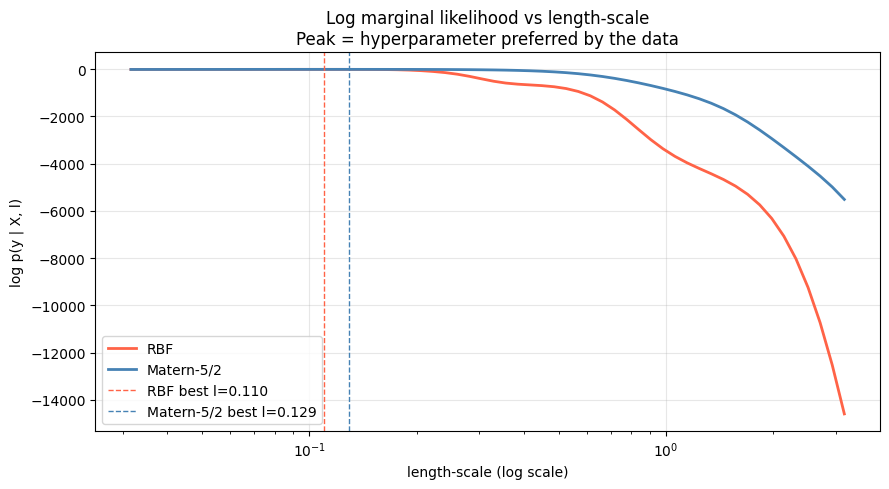

Best RBF length-scale:      0.110
Best Matern-5/2 length-scale: 0.129


In [9]:
ls_values = np.logspace(-1.5, 0.5, 60)   # 0.03 … 3.0

lml_rbf = [log_marginal_likelihood(X_tr8, y_tr8,
            lambda X1, X2, ls=ls: rbf(X1, X2, length_scale=ls, signal_var=4.0))
           for ls in ls_values]
lml_m52 = [log_marginal_likelihood(X_tr8, y_tr8,
            lambda X1, X2, ls=ls: matern52(X1, X2, length_scale=ls, signal_var=4.0))
           for ls in ls_values]

best_ls_rbf = ls_values[np.argmax(lml_rbf)]
best_ls_m52 = ls_values[np.argmax(lml_m52)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ls_values, lml_rbf, color="tomato",    linewidth=2, label="RBF")
ax.plot(ls_values, lml_m52, color="steelblue", linewidth=2, label="Matern-5/2")
ax.axvline(best_ls_rbf, color="tomato",    linestyle="--", linewidth=1,
           label=f"RBF best l={best_ls_rbf:.3f}")
ax.axvline(best_ls_m52, color="steelblue", linestyle="--", linewidth=1,
           label=f"Matern-5/2 best l={best_ls_m52:.3f}")
ax.set_xscale("log")
ax.set_title("Log marginal likelihood vs length-scale\nPeak = hyperparameter preferred by the data")
ax.set_xlabel("length-scale (log scale)")
ax.set_ylabel("log p(y | X, l)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best RBF length-scale:      {best_ls_rbf:.3f}")
print(f"Best Matern-5/2 length-scale: {best_ls_m52:.3f}")

**Try it:** Sweep `signal_var` at the same time. Create a 2D grid of (length_scale, signal_var) and plot the log marginal likelihood as a heatmap — this is Exercise 2 in the README.

## Part 6 — 2D GP on the Branin function

Everything generalises to multiple dimensions — the kernel computes pairwise distances in $\mathbb{R}^d$ instead of $\mathbb{R}^1$. The GP fit, uncertainty, and log marginal likelihood work identically.

The **Branin function** is a standard 2D benchmark with three global minima, used throughout the optimisation literature.

> **Cost of GPs in 2D and beyond:** training is still $O(n^3)$ in the number of training points, not in the number of dimensions. However, to cover a $d$-dimensional space well you need exponentially more points — this is why GPs struggle in high dimensions. Neural network surrogates (Lessons 10–11) do not have this limitation.

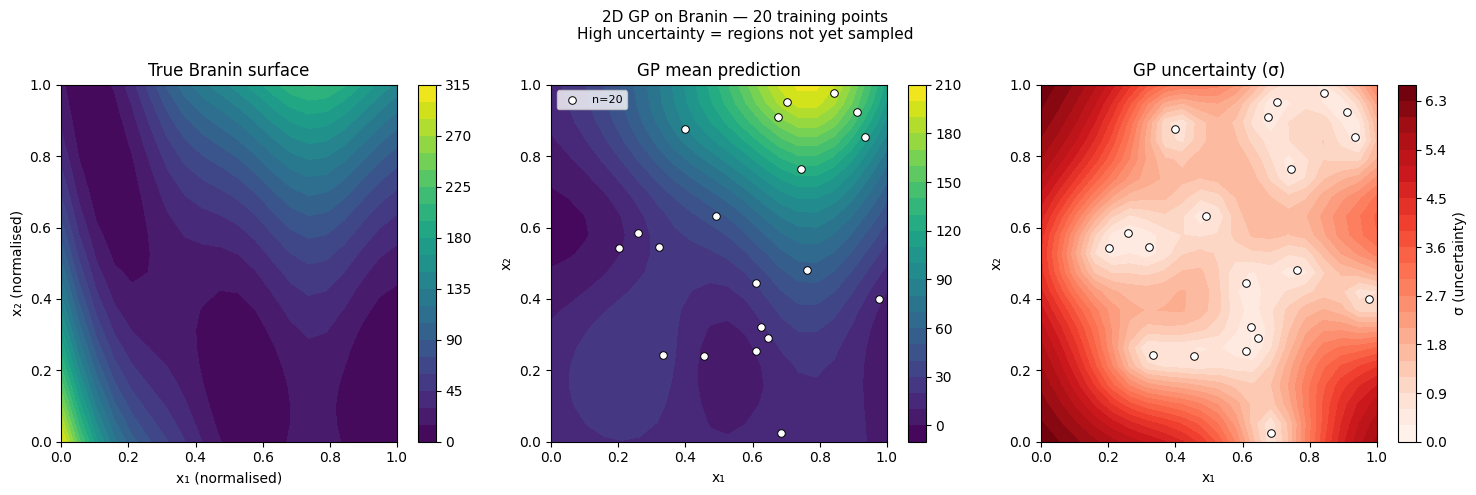

In [10]:
n_train_2d = 20
X_2d = rng.uniform(0, 1, (n_train_2d, 2))
y_2d = branin_norm(X_2d)

grid_res = 20
g = np.linspace(0, 1, grid_res)
G1, G2 = np.meshgrid(g, g)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])
y_true_grid = branin_norm(X_grid).reshape(grid_res, grid_res)

kern_2d = lambda X1, X2: matern52(X1, X2, length_scale=0.3, signal_var=50.0)
mu_grid, std_grid = gp_predict(X_2d, y_2d, X_grid, kern_2d, noise=0.1)
mu_grid  = mu_grid.reshape(grid_res, grid_res)
std_grid = std_grid.reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cf0 = axes[0].contourf(G1, G2, y_true_grid, levels=20, cmap="viridis")
plt.colorbar(cf0, ax=axes[0])
axes[0].set_title("True Branin surface")
axes[0].set_xlabel("x₁ (normalised)"); axes[0].set_ylabel("x₂ (normalised)")

cf1 = axes[1].contourf(G1, G2, mu_grid, levels=20, cmap="viridis")
plt.colorbar(cf1, ax=axes[1])
axes[1].scatter(X_2d[:,0], X_2d[:,1], color="white", s=30,
                edgecolors="black", linewidths=0.7, zorder=5, label=f"n={n_train_2d}")
axes[1].set_title("GP mean prediction")
axes[1].set_xlabel("x₁"); axes[1].set_ylabel("x₂")
axes[1].legend(fontsize=8)

cf2 = axes[2].contourf(G1, G2, std_grid, levels=20, cmap="Reds")
plt.colorbar(cf2, ax=axes[2], label="σ (uncertainty)")
axes[2].scatter(X_2d[:,0], X_2d[:,1], color="white", s=30,
                edgecolors="black", linewidths=0.7, zorder=5)
axes[2].set_title("GP uncertainty (σ)")
axes[2].set_xlabel("x₁"); axes[2].set_ylabel("x₂")

plt.suptitle(f"2D GP on Branin — {n_train_2d} training points\n"
             "High uncertainty = regions not yet sampled", fontsize=11)
plt.tight_layout()
plt.show()

**Key insight:** The uncertainty map (right panel) shows exactly where the GP has no information. An acquisition function (Lesson 7) will use this map to decide where to evaluate the expensive function next.

**Why neural networks win in higher dimensions:**
- GP in 2D with 20 points: good coverage is possible
- GP in 10D with 20 points: 20 points barely scratch the surface of a 10D hypercube
- GP training cost: $O(n^3)$ — but $n$ must grow exponentially with $d$ to cover the space
- NN training cost: $O(n \cdot \text{epochs} \cdot \text{params})$ — does not depend on $d$ the same way
- NNs also *learn* their own similarity function from data, rather than assuming a fixed kernel shape

## Summary

| Concept | Formula / Code |
|---|---|
| GP posterior mean | `mu = Ks @ solve(K, y)` |
| GP posterior std | `std = sqrt(diag(Kss) - sum(v**2, axis=0))` |
| Noise model | `K + noise * eye(n)` |
| Hyperparameter selection | maximise `log_marginal_likelihood` |
| Preferred kernel | Matern-5/2 for most engineering functions |
| GP limitation | $O(n^3)$ training, needs exponentially more points in high $d$ |

**Next lesson:** Given the GP posterior mean $\mu(x)$ and std $\sigma(x)$, how do we decide where to evaluate the expensive function next? → Acquisition functions (PI, EI, UCB).